In [1]:
#Montar Drive

from google.colab import drive
drive.mount('/content/drive')

import os

#Definimos la ruta de Drive para guardar los checkpoints
RUTA_DRIVE = '/content/drive/MyDrive/SRGAN_WBC_Checkpoint/'
if not os.path.exists(RUTA_DRIVE):
  os.makedirs(RUTA_DRIVE)

print("Google Drive conectado y ruta de checkpoints configurada.")

Mounted at /content/drive
Google Drive conectado y ruta de checkpoints configurada.


In [2]:
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.layers import Input, Reshape, Dropout, Dense
from tensorflow.keras.layers import Flatten, BatchNormalization
from tensorflow.keras.layers import Activation, ZeroPadding2D
from tensorflow.keras.layers import LeakyReLU
from tensorflow.keras.layers import UpSampling2D, Conv2D
from tensorflow.keras.models import Sequential, Model, load_model
from tensorflow.keras.optimizers import Adam, SGD
import numpy as np
from PIL import Image
import os
import matplotlib.pyplot as plt
from keras.models import load_model
import cv2    #para visión artificial y procesamiento de imágenes o video en tiempo real
from keras import layers, Model

# **SRGAN**

## *Preprocesamiento*

In [3]:
from sklearn.model_selection import train_test_split

import numpy as np
from keras import Model
from keras.layers import Conv2D, PReLU,BatchNormalization, Flatten
from keras.layers import UpSampling2D, LeakyReLU, Dense, Input, add

#Definimos la ruta base en Drive
BASE_DIR = '/content/drive/MyDrive/WBC_dataset'
TRAIN_DIR = os.path.join(BASE_DIR, 'images/TRAIN')
OUT_PATH_HR = os.path.join(BASE_DIR, 'hr_images')
OUT_PATH_LR = os.path.join(BASE_DIR, 'lr_images')
CHECKPOINT_DIR = '/content/drive/MyDrive/SRGAN_WBC_Checkpoint'

# Crear directorios si no existen
for path in [OUT_PATH_HR, OUT_PATH_LR, CHECKPOINT_DIR]:
    if not os.path.exists(path):
        os.makedirs(path)

Data Augmentation (preprocess)

In [ ]:

############
# La libreria ImageDataGenerator es una libreria especifica de python para hacer
# data augmentation (ahorr RAM porque las crea "on the fly", en el momento)
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array

print("Iniciando el aumento de datos (Data Augmentation)...")

# Parámetros del artículo
data_gen_args = dict(
    rotation_range=15,  #rotación será un número aleatorio entre -15° y +15°
    width_shift_range=0.1,  #mueve la foto un número aleatorio entre un -10% y un 10% a lo ancho
    height_shift_range=0.1, #mueve la foto un número aleatorio entre un -10% y un 10% a lo alto
    shear_range=0.2,  #cizalladura aleatoria entre -20% y 20%
    zoom_range=0.2, #zoom in o zoom out wn un -20% a 20%
    horizontal_flip=True, #como lop iden en el artículo
    fill_mode='nearest' #Al hacer zoom out los espacios se llenan duplicando los pixeles más cercanos
    )

image_datagen = ImageDataGenerator(**data_gen_args)
#############

classes = ['NEUTROPHIL', 'EOSINOPHIL', 'MONOCYTE', 'LYMPHOCYTE']

# Recorremos cada clase para generar las nuevas imágenes
for c in classes:
    class_path = os.path.join(TRAIN_DIR, c)
    if not os.path.exists(class_path):
        continue

    archivos = os.listdir(class_path)
    print(f"Generando variaciones para la clase: {c}...")

    for img_name in archivos:
        # Evitamos que el código aumente imágenes que ya fueron aumentadas
        if img_name.startswith("aug_"):
            continue

        # Solo procesamos si el archivo termina en una extensión de imagen válida
        if not img_name.lower().endswith(('.jpeg')):
            continue

        img_path = os.path.join(class_path, img_name)

        # Cargar la imagen "cruda" y prepararla para el generador
        img = load_img(img_path)
        x = img_to_array(img)
        x = x.reshape((1,) + x.shape) # Keras requiere formato (batch, alto, ancho, canales)

        # Generar 2 imágenes nuevas (variaciones) por cada imagen original
        i = 0
        for batch in image_datagen.flow(x, batch_size=1, save_to_dir=class_path, save_prefix="aug", save_format='jpg'):
            i += 1
            if i >= 2:
                break

print("Aumento de datos finalizado.")

Iniciando el aumento de datos (Data Augmentation)...
Generando variaciones para la clase: NEUTROPHIL...
Generando variaciones para la clase: EOSINOPHIL...
Generando variaciones para la clase: MONOCYTE...
Generando variaciones para la clase: LYMPHOCYTE...
Aumento de datos finalizado.


Filtro Gaussiano (preprocess)

In [ ]:
import os
print("Aplicando el filtro Gaussiano.")

# Función para procesar y guardar las imágenes con el filtro Gaussiano faltante
# mencionado en el artículo
def process_images_to_drive(class_name):
    class_path = os.path.join(TRAIN_DIR, class_name)
    if not os.path.exists(class_path):
        return

    # Crear subcarpetas específicas para esta clase en HR y LR
    hr_class_dir = os.path.join(OUT_PATH_HR, class_name)
    lr_class_dir = os.path.join(OUT_PATH_LR, class_name)

    if not os.path.exists(hr_class_dir): os.makedirs(hr_class_dir)
    if not os.path.exists(lr_class_dir): os.makedirs(lr_class_dir)

    for img_name in os.listdir(class_path):
        img_array = cv2.imread(os.path.join(class_path, img_name))
        if img_array is None: continue

        # HR Image (128x128)
        hr_img_array = cv2.resize(img_array, (128, 128))

        # Aplicamos el filtro Gaussiano mencionado en el artículo antes de reducir.
        # Simula el desenfoque real del microscopio. Destruye información detallada
        # intencionalmente para forzar al Generador a reconstruir y deducir las
        # las texturas biológicas originales
        blurred = cv2.GaussianBlur(hr_img_array, (5,5), 0)

        # LR Image (32x32)
        lr_img_array = cv2.resize(blurred, (32, 32))

        # Guardamos dentro de la subcarpeta de su clase correspondiente
        cv2.imwrite(os.path.join(hr_class_dir, img_name), hr_img_array)
        cv2.imwrite(os.path.join(lr_class_dir, img_name), lr_img_array)

# Procesamos las 4 clases
classes = ['NEUTROPHIL', 'EOSINOPHIL', 'MONOCYTE', 'LYMPHOCYTE']
for c in classes:
    print(f"Procesando imágenes de la clase {c}...")
    process_images_to_drive(c)
    print(f"Pares LR/HR generados para la clase {c}.")
print("Clases procesadas.")


Aplicando el filtro Gaussiano.
Procesando imágenes de la clase NEUTROPHIL...
Pares LR/HR generados para la clase NEUTROPHIL.
Procesando imágenes de la clase EOSINOPHIL...
Pares LR/HR generados para la clase EOSINOPHIL.
Procesando imágenes de la clase MONOCYTE...
Pares LR/HR generados para la clase MONOCYTE.
Procesando imágenes de la clase LYMPHOCYTE...
Pares LR/HR generados para la clase LYMPHOCYTE.
Clases procesadas.


#####Para el GENERADOR

In [4]:
# Sub-bloques y modelo completo del Generador (añadiendo el kernel_initializer)
def res_block(ip):
    res_model = Conv2D(64, (3,3), padding="same", kernel_initializer=init)(ip)  #Notación de keras para refactorización
    res_model = BatchNormalization(momentum=0.5)(res_model)
    res_model = PReLU(shared_axes=[1,2])(res_model)
    res_model = Conv2D(64, (3,3), padding="same", kernel_initializer=init)(res_model)
    res_model = BatchNormalization(momentum=0.5)(res_model)
    return add([ip, res_model])

def upscale_block(ip):
    up_model = Conv2D(256, (3,3), padding="same", kernel_initializer=init)(ip)
    up_model = UpSampling2D(size=2)(up_model)
    up_model = PReLU(shared_axes=[1,2])(up_model)
    return up_model

# GENERADOR
def create_gen(gen_ip, num_res_block):
    layers = Conv2D(64, (9,9), padding="same", kernel_initializer=init)(gen_ip)
    layers = PReLU(shared_axes=[1,2])(layers)
    temp = layers
    for i in range(num_res_block):
        layers = res_block(layers)
    layers = Conv2D(64, (3,3), padding="same", kernel_initializer=init)(layers)
    layers = BatchNormalization(momentum=0.5)(layers)
    layers = add([layers, temp])
    layers = upscale_block(layers)
    layers = upscale_block(layers)
    op = Conv2D(3, (9,9), padding="same", activation="sigmoid", kernel_initializer=init)(layers)
    return Model(inputs=gen_ip, outputs=op) # Empaquetando las capas del modelo

##### Para el DISCRIMINADOR

In [5]:
# Sub-bloques y modelo completo del Discriminador
def discriminator_block(ip, filters, strides=1, bn=True):
    disc_model = Conv2D(filters, (3,3), strides=strides, padding="same", kernel_initializer=init)(ip)
    if bn:
        disc_model = BatchNormalization(momentum=0.8)(disc_model)
    disc_model = LeakyReLU(negative_slope=0.2)(disc_model)
    return disc_model

# DISCRIMINADOR
def create_disc(disc_ip):
    df = 64
    d1 = discriminator_block(disc_ip, df, bn=False)
    d2 = discriminator_block(d1, df, strides=2)
    d3 = discriminator_block(d2, df*2)
    d4 = discriminator_block(d3, df*2, strides=2)
    d5 = discriminator_block(d4, df*4)
    d6 = discriminator_block(d5, df*4, strides=2)
    d7 = discriminator_block(d6, df*8)
    d8 = discriminator_block(d7, df*8, strides=2)

    d8_5 = Flatten()(d8)
    d9 = Dense(df*16, kernel_initializer=init)(d8_5)
    d10 = LeakyReLU(alpha=0.2)(d9)
    validity = Dense(1, activation='sigmoid', kernel_initializer=init)(d10)
    return Model(disc_ip, validity) # Empaquetando las capas del modelo

*VGG19*

In [6]:
#We need VGG19 for the feature map obtained by the j-th convolution (after activation)
#before the i-th maxpooling layer within the VGG19 network.(as described in the paper)
#Let us pick the 3rd block, last conv layer.
#Build a pre-trained VGG19 model that outputs image features extracted at the
# third block of the model
# VGG architecture: https://github.com/keras-team/keras/blob/master/keras/applications/vgg19.py

from tensorflow.keras.applications import VGG19

# Basado en la Sección 3.2.1 del artículo (Ecuación 6)
def build_vgg(hr_shape):
    # En el artículo mencionan que en lugar de usar el MSE tradicional píxel por píxel,
    # extraen mapas de características generados por la red VGG19 preentrenada (con la
    # base de datos de ImageNet)
    vgg = VGG19(weights="imagenet", include_top=False, input_shape=hr_shape)

    # En el artículo hacen referencia a los feature maps obtenidos en capas profundas
    # Extraer la capa 20 (usualmente block5_conv4 en VGG19) es la convención
    # matemática estándar para capturar texturas finas en las SRGANs
    return Model(inputs=vgg.inputs, outputs=vgg.layers[20].output)  #En el original tenían 10
                                                                    #Modificado por convención

#Combined model
# Integra los componentes para la Ecuación 4: l^SR = l_X^SR + (10^-3 * l_gen^SR)
# respecto a la función de pérdida
def create_comb(gen_model, disc_model, vgg, lr_ip, hr_ip):
    gen_img = gen_model(lr_ip)

    # Esta salida se usará en la compilación para la Pérdida de Contenido (Eq. 6)
    gen_features = vgg(gen_img)

    # Congelamos el discriminador porque durante este paso SOLO estamos
    # actualizando los pesos (backpropagation) del Generador
    disc_model.trainable = False
    validity = disc_model(gen_img)

    # El modelo combinado expone dos salidas simultáneas para aplicar
    # ambas funciones de pérdida al mismo tiempo
    return Model(inputs=[lr_ip, hr_ip], outputs=[validity, gen_features])

In [7]:
from tensorflow.keras.initializers import RandomNormal

# Definimos el inicializador basado en las especificaciones: mencionan específicamente
# que usaron un inicializador aleatorio para la capa de entrada con media 0
# Nota: usamos stddev=0.02 para evitar el colapso matemático del gradiente (en el artículo dicen que usaron stddev=0.0, ¿por qué?)
init = RandomNormal(mean=0.0, stddev=0.02)

# **ENTRENAMIENTO**

In [8]:
import random
import os

print("Cargando una muestra representativa desde Drive...")

# Clases: 'NEUTROPHIL', 'EOSINOPHIL', 'MONOCYTE', 'LYMPHOCYTE'
clase_actual = 'LYMPHOCYTE'

classes = [clase_actual]
epochs = 200    # Propuesto en el artículo
batch_size = 4  # Propuesto en el artículo

print("\n~Se hará un entrenamiento por cada clase (4) de la SRGAN...\n")

for c in classes:
    print(f"\n{'='*50}")  #Formato
    print(f" Iniciando entrenamiento SRGAN para la clase: {c}")
    print(f"{'='*50}\n")  #Formato

    lr_class_images = []
    hr_class_images = []

    # Cargamos TODAS las imágenes de la clase actual

    lr_class_dir = os.path.join(OUT_PATH_LR, c)
    hr_class_dir = os.path.join(OUT_PATH_HR, c)

    archivos_clase = os.listdir(lr_class_dir)

    # PARA QUE SEA MÁS RÁPIDO USAMOS SÓLO 500     ########
    archivos_clase = random.sample(archivos_clase, 500)

    print(f"Cargando {len(archivos_clase)} imágenes de {c} desde subcarpeta...")

    for img_name in archivos_clase:
        # cargar LR desde la subcarpeta
        img_lr = cv2.imread(os.path.join(lr_class_dir, img_name))
        if img_lr is None: continue
        img_lr = cv2.cvtColor(img_lr, cv2.COLOR_BGR2RGB)
        lr_class_images.append(img_lr)

        # cargar HR desde la subcarpeta
        img_hr = cv2.imread(os.path.join(hr_class_dir, img_name))
        img_hr = cv2.cvtColor(img_hr, cv2.COLOR_BGR2RGB)
        hr_class_images.append(img_hr)

    ### PREPROCESAMIENTO

    # Normalizamos, dtype=np.float32 es por lo que devuelve cv2
    lr_images_full = np.array(lr_class_images, dtype=np.float32) / 255.0
    hr_images_full = np.array(hr_class_images, dtype=np.float32) / 255.0

    # Partición: 80% Train, 20% restante
    lr_train, lr_rest, hr_train, hr_rest = train_test_split(
        lr_images_full, hr_images_full, test_size=0.20, random_state=42
    )

    # Partición del restante: 50% Val, 50% Test (10% y 10% del total original)
    lr_val, lr_test, hr_val, hr_test = train_test_split(
        lr_rest, hr_rest, test_size=0.50, random_state=42
    )

    ###

    # Construimos (o reseteamos) los modelos específicos para esta clase
    hr_shape = (hr_train.shape[1], hr_train.shape[2], hr_train.shape[3])
    lr_shape = (lr_train.shape[1], lr_train.shape[2], lr_train.shape[3])

    lr_ip = Input(shape=lr_shape)
    hr_ip = Input(shape=hr_shape)

    # Generador con activación sigmoide (al final)
    generator = create_gen(lr_ip, num_res_block=16)

    opt_disc = Adam(learning_rate=1e-4, beta_1=0.9)
    discriminator = create_disc(hr_ip)

    # "binary_crossentropy" ejecuta la Ecuación 7: calcula la sumatoria de
    # -> -log(D(G(I^LR))) para engañar al discriminador
    # "mse" ejecuta la Ecuación 6: calcula la distancia euclidiana al cuadrado
    # -> entre los mapas de características de la VGG19
    # loss_weights aplica el factor de escala exactamente como dicta la Ecuación 4:
    # -> 1e-3 (10^-3) pondera la primera salida (Pérdida Adversarial)
    # -> 1 pondera la segunda salida (Pérdida de Contenido Perceptual)
    discriminator.compile(loss="binary_crossentropy", optimizer=opt_disc, metrics=['accuracy'])

    # VGG19 (capa 20 para perceptual loss)
    vgg = build_vgg((128, 128, 3))
    vgg.trainable = False #"congelamos" los gradientes (indica si hace backpropagtion)

    # Usamos la vgg para obtener un mejor resultado (apoyo para el discriminador)
    # tal y como mencionan en el artículo
    # El discriminador asegura que la imagen parezca real. La VGG19 asegura que
    # la imagen conserve los detalles, la identidad y las texturas exactas de la
    # célula original porque analiza sus feature maps
    opt_gan = Adam(learning_rate=1e-4, beta_1=0.9)
    gan_model = create_comb(generator, discriminator, vgg, lr_ip, hr_ip)
    gan_model.compile(loss=["binary_crossentropy", "mse"], loss_weights=[1e-3, 1], optimizer=opt_gan)

    # Preparamos los batches para la clase actual
    train_lr_batches = []
    train_hr_batches = []
    for it in range(int(hr_train.shape[0] / batch_size)):
        start_idx = it * batch_size
        end_idx = start_idx + batch_size
        train_hr_batches.append(hr_train[start_idx:end_idx])
        train_lr_batches.append(lr_train[start_idx:end_idx])

    # Ciclo de entrenamiento por clase
    for e in range(epochs):
        fake_label = np.zeros((batch_size, 1))
        real_label = np.ones((batch_size, 1))
        g_losses, d_losses = [], []

        for b in range(len(train_hr_batches)):
            lr_imgs = train_lr_batches[b]
            hr_imgs = train_hr_batches[b]

            fake_imgs = generator.predict_on_batch(lr_imgs)

            # Hacemos backpropagation para entrenar primero al discriminador
            discriminator.trainable = True

            # Entrenamos al discriminador en dos batches separados
            d_loss_gen = discriminator.train_on_batch(fake_imgs, fake_label)
            d_loss_real = discriminator.train_on_batch(hr_imgs, real_label)

            # Detenemos o "apagamos" el backpropagation del discriminador para que
            # no actualice sus pesos
            discriminator.trainable = False

            # Calculamos el error promedio Ecuación 3 (convención estándar en GANs)
            d_loss = 0.5 * np.add(d_loss_gen, d_loss_real)

            # Extraemos los mapas de características de las imágenes de HR
            image_features = vgg.predict_on_batch(hr_imgs)

            # Entrenamos el modelo con lo que queremos que logre (targets)
            g_loss, _, _ = gan_model.train_on_batch([lr_imgs, hr_imgs], [real_label, image_features])

            d_losses.append(d_loss)
            g_losses.append(g_loss)

        if (e+1) % 10 == 0:
            print(f"Época {e+1}/{epochs} | {c} | G_loss: {np.mean(g_losses):.4f} | D_loss: {np.mean(d_losses):.4f}")

            # Creamos una subcarpeta para los checkpoints de esta clase específica
            checkpoint_class_dir = os.path.join(CHECKPOINT_DIR, c)
            if not os.path.exists(checkpoint_class_dir):
                os.makedirs(checkpoint_class_dir)

            # Guardamos el modelo dentro de su carpeta
            gen_save_path = os.path.join(checkpoint_class_dir, f"{c}_generator_epoch_{e+1}.keras")
            generator.save(gen_save_path)

    print(f"Entrenamiento de {c} finalizado. Modelos guardados en Drive.\n")

Cargando una muestra representativa desde Drive...

~Se hará un entrenamiento por cada clase (4) de la SRGAN...


 Iiniciando entrenamiento SRGAN para la clase: LYMPHOCYTE

Cargando 500 imágenes de LYMPHOCYTE desde subcarpeta...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
Época 10/200 | LYMPHOCYTE | G_loss: 0.0235 | D_loss: 0.5019
Época 20/200 | LYMPHOCYTE | G_loss: 0.0181 | D_loss: 0.5096
Época 30/200 | LYMPHOCYTE | G_loss: 0.0142 | D_loss: 0.5064
Época 40/200 | LYMPHOCYTE | G_loss: 0.0118 | D_loss: 0.5047
Época 50/200 | LYMPHOCYTE | G_loss: 0.0104 | D_loss: 0.5088
Época 60/200 | LYMPHOCYTE | G_loss: 0.0092 | D_loss: 0.5080
Época 70/200 | LYMPHOCYTE | G_loss: 0.0082 | D_loss: 0.5069
Época 80/200 | LYMPHOCYTE | G_loss: 0.0076 | D_loss: 0.5114
Época 90/200 | LYMPHOCYTE | G_loss: 0.0069 | D_loss: 0.5101
Época 100/200 | LYMPHOCYTE | G_loss: 0.0065 | D_loss: 0.5157
Época 110/200 | LYMPHOCYTE | G_loss: 0.0061 | D_loss: 0.5155
Época 120/200 | LYMPHOCYTE | G_loss: 0.0057 | D_loss: 0.5142
Época 130/200 | LYMPHOCYTE | G_loss: 0.0054 | D_loss: 0.5131
Época 140/200 | LYMPHOCYTE | G_loss: 0.0051 | D_loss: 0.5121
Época 150/200 | LYMPHOCYTE | G_loss: 0.0049 | D_loss: 0.5113
Época 160/200 | LYMPHOCYTE | G_loss: 0.0047

# **VISUALIZACIÓN**

Cargando el modelo: /content/drive/MyDrive/SRGAN_WBC_Checkpoint/LYMPHOCYTE/LYMPHOCYTE_generator_epoch_200.keras
Evaluando la imagen: _0_2667.jpeg
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Imagen guardada en:
/content/drive/MyDrive/SRGAN_Resultados/Comparacion_LYMPHOCYTE__0_2667.png


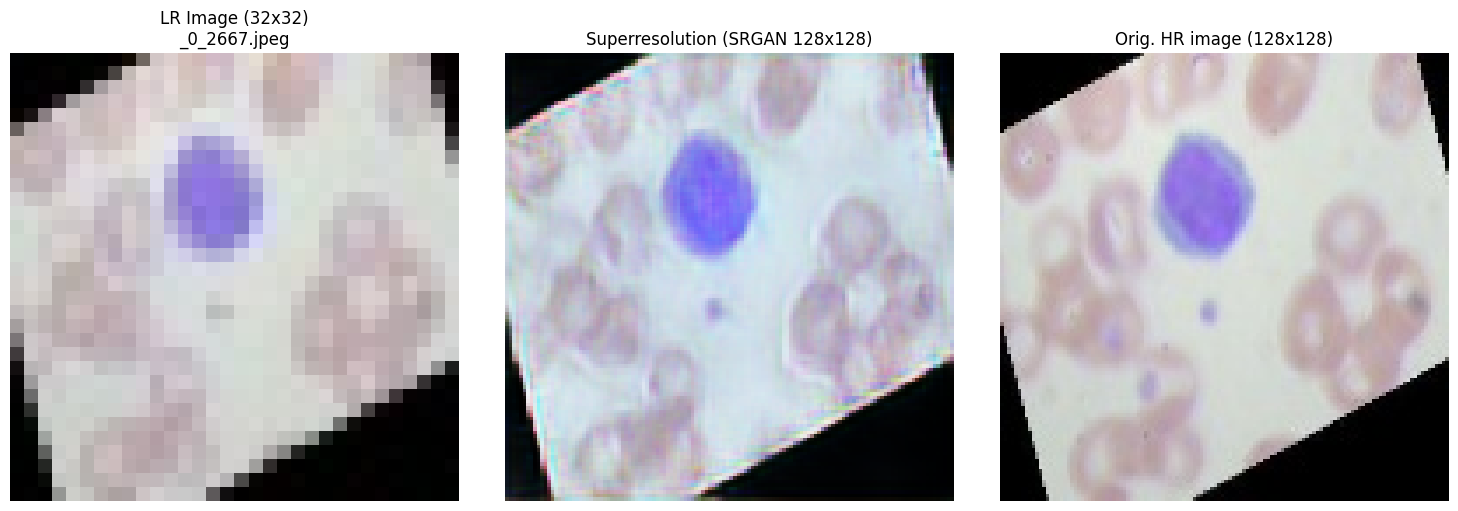

In [19]:
import matplotlib.pyplot as plt
from keras.models import load_model
import numpy as np
import random
import cv2
import os

# Definimos qué modelo cargar
clase_eval = 'LYMPHOCYTE'
epoca_eval = 200

# Nueva carpeta en Drive para guardar los resultados
RESULTADOS_DIR = '/content/drive/MyDrive/SRGAN_Resultados'
if not os.path.exists(RESULTADOS_DIR):
    os.makedirs(RESULTADOS_DIR)

# Definimos la ruta a Drive
modelo_path = os.path.join(CHECKPOINT_DIR, clase_eval, f"{clase_eval}_generator_epoch_{epoca_eval}.keras")

print(f"Cargando el modelo: {modelo_path}")

# compile=False para indicar que vamos a predecir, no a entrenar
generator_eval = load_model(modelo_path, compile=False)

# Definimos las rutas a las subcarpetas de las imágenes
lr_class_dir = os.path.join(OUT_PATH_LR, clase_eval)
hr_class_dir = os.path.join(OUT_PATH_HR, clase_eval)

# Guardamos todos los archivos que pertenezcan a la clase elegida
archivos_clase = os.listdir(lr_class_dir)
img_random = random.choice(archivos_clase) # Escoger una al azar

print(f"Evaluando la imagen: {img_random}")

# Cargar imagen LR (Baja resolución)
img_lr = cv2.imread(os.path.join(lr_class_dir, img_random))
img_lr = cv2.cvtColor(img_lr, cv2.COLOR_BGR2RGB)
img_lr = np.array(img_lr, dtype=np.float32) / 255.0

# Cargar imagen HR original (Para comparar)
img_hr = cv2.imread(os.path.join(hr_class_dir, img_random))
img_hr = cv2.cvtColor(img_hr, cv2.COLOR_BGR2RGB)
img_hr = np.array(img_hr, dtype=np.float32) / 255.0

# Keras requiere que la imagen tenga formato de "lote" (Batch, Alto, Ancho, Canales)
# expand_dims le agrega ese "1" extra al principio de las dimensiones
img_lr_batch = np.expand_dims(img_lr, axis=0)

# Generamos la imagen a partir de la de baja resolución
gen_image = generator_eval.predict(img_lr_batch)

# Graficar
plt.figure(figsize=(15, 5))

plt.subplot(131)
plt.title(f'LR Image (32x32)\n{img_random}')
plt.imshow(img_lr)
plt.axis('off')

plt.subplot(132)
plt.title('Superresolution (SRGAN 128x128)')
plt.imshow(gen_image[0])
plt.axis('off')

plt.subplot(133)
plt.title('Orig. HR image (128x128)')
plt.imshow(img_hr)
plt.axis('off')

plt.tight_layout()  # Ajustado automático de matplotlib

# Generamos un nombre único para la gráfica para que no se sobrescriban
nombre_archivo = f"Comparacion_{clase_eval}_{img_random.split('.')[0]}.png"
ruta_guardado = os.path.join(RESULTADOS_DIR, nombre_archivo)

# Guardamos la gráfica
plt.savefig(ruta_guardado, bbox_inches='tight')
print(f"Imagen guardada en:\n{ruta_guardado}")

plt.show()